In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('marketing_AB.csv')

# Display first rows
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [6]:
# Remove unused columns
df.drop(columns=['Unnamed: 0', 'user id'], inplace=True)

# Display first rows
df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [7]:
# Basic shape and info
print("Shape:", df.shape)
print(df.info())

# Summary stats for numeric columns
df.describe().T

Shape: (588101, 5)
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   test group     588101 non-null  str  
 1   converted      588101 non-null  bool 
 2   total ads      588101 non-null  int64
 3   most ads day   588101 non-null  str  
 4   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(2), str(2)
memory usage: 18.5 MB
None


,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


In [8]:
# Unique values
print("Test group:", df['test group'].unique())
print("Converted:", df['converted'].unique())
print("Most ads day:", df['most ads day'].unique())

Test group: <StringArray>
['ad', 'psa']
Length: 2, dtype: str
Converted: [False  True]
Most ads day: <StringArray>
['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday', 'Thursday']
Length: 7, dtype: str


In [9]:
df['converted']

0         False
1         False
2         False
3         False
4         False
          ...  
588096    False
588097    False
588098    False
588099    False
588100    False
Name: converted, Length: 588101, dtype: bool

In [10]:
# Convert boolean to integer for numerical tests
df['converted'] = df['converted'].astype(int)

df.dtypes

test group         str
converted        int64
total ads        int64
most ads day       str
most ads hour    int64
dtype: object

In [11]:
df['converted']

0         0
1         0
2         0
3         0
4         0
         ..
588096    0
588097    0
588098    0
588099    0
588100    0
Name: converted, Length: 588101, dtype: int64

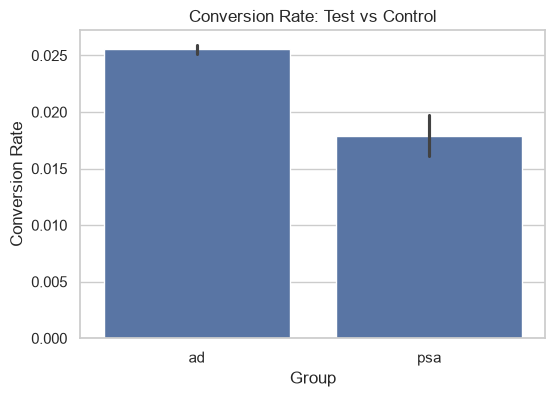

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='test group', y='converted')
plt.title("Conversion Rate: Test vs Control")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

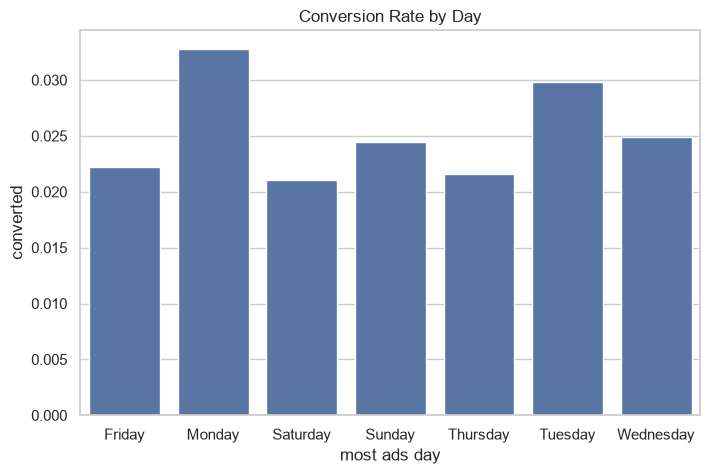

In [13]:
day_rate = df.groupby('most ads day')['converted'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=day_rate, x='most ads day', y='converted')
plt.title("Conversion Rate by Day")
plt.show()

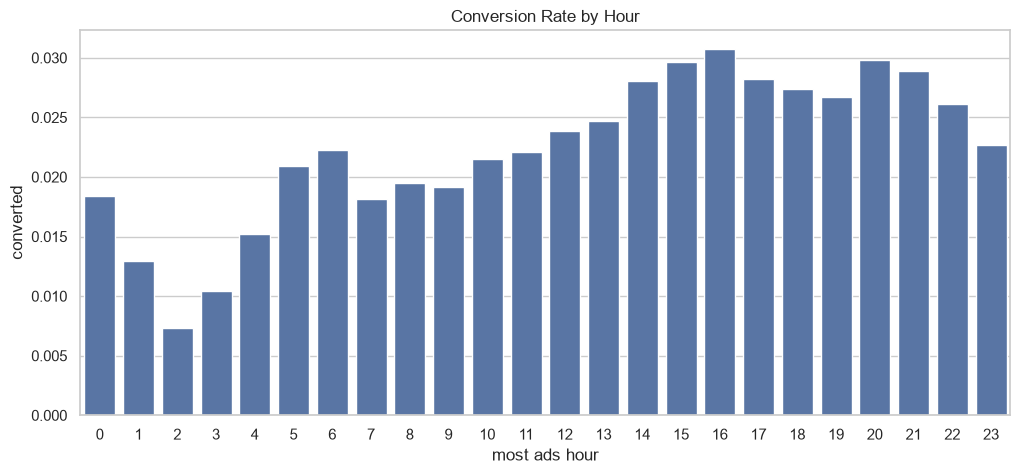

In [14]:
hour_rate = df.groupby('most ads hour')['converted'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=hour_rate, x='most ads hour', y='converted')
plt.title("Conversion Rate by Hour")
plt.show()

In [15]:
control_group = df[df['test group'] == 'psa']
test_group = df[df['test group'] == 'ad']

control_conv = control_group['converted']
test_conv = test_group['converted']

t_stat , p_val = stats.ttest_ind(test_conv , control_conv)

print("t-statistic:", t_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Result: Reject H0 -> Significant difference in conversion rates")
else:
    print("Result: Fail to reject h0 -> No significant difference")

t-statistic: 7.370405974285658
P-value: 1.703305262783145e-13
Result: Reject H0 -> Significant difference in conversion rates


In [16]:
anova_day = stats.f_oneway(*[
    df[df['most ads day'] == day]['converted']
    for day in df['most ads day'].unique()
])

print("ANOVA — Most Ads Day")
print("F-statistic:", anova_day.statistic)
print("P-value:", anova_day.pvalue)

if anova_day.pvalue < 0.05:
    print("Result: Reject H0 -> Day significantly affects conversion.")
else:
    print("Result: Fail to reject H0 -> No effect of day.")

ANOVA — Most Ads Day
F-statistic: 68.3881838689767
P-value: 1.8032007658097884e-85
Result: Reject H0 -> Day significantly affects conversion.


In [17]:
anova_hour = stats.f_oneway(*[
    df[df['most ads hour'] == hr]['converted']
    for hr in sorted(df['most ads hour'].unique())
])

print("ANOVA — Most Ads Hour")
print("F-statistic:", anova_hour.statistic)
print("P-value:", anova_hour.pvalue)

if anova_hour.pvalue < 0.05:
    print("Result: Reject H0 -> Hour significantly affects conversion.")
else:
    print("Result: Fail to reject H0.")

ANOVA — Most Ads Hour
F-statistic: 18.742037312973135
P-value: 7.482025334603263e-77
Result: Reject H0 -> Hour significantly affects conversion.


In [19]:
import numpy as np
from scipy import stats

n = np.array([len(test_conv), len(control_conv)])
x = np.array([test_conv.sum(), control_conv.sum()])
p_test, p_ctrl = x / n

# Two-proportion z-test (pooled)
p_pool = x.sum() / n.sum()
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n[0] + 1/n[1]))
z_stat = (p_test - p_ctrl) / se_pool
p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# 95% CI for the difference (unpooled)
diff = p_test - p_ctrl
se = np.sqrt(p_test*(1-p_test)/n[0] + p_ctrl*(1-p_ctrl)/n[1])
ci = (diff - 1.96*se, diff + 1.96*se)

print(f"Conversion: ad={p_test:.4%}, psa={p_ctrl:.4%}")
print(f"Absolute lift: {diff:.4%}  (95% CI: {ci[0]:.4%} to {ci[1]:.4%})")
print(f"Relative lift: {diff/p_ctrl:.1%}")
print(f"z = {z_stat:.3f}, p = {p_val:.4g}")

Conversion: ad=2.5547%, psa=1.7854%
Absolute lift: 0.7692%  (95% CI: 0.5951% to 0.9434%)
Relative lift: 43.1%
z = 7.370, p = 1.705e-13


In [20]:
ct = pd.crosstab(df['most ads day'], df['converted'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p:.4g}")

Chi-square = 410.05, dof = 6, p = 1.932e-85


In [21]:
import numpy as np
from itertools import combinations

# Effect size: Cramér's V
chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df['most ads day'], df['converted']))
n_total = len(df)
cramers_v = np.sqrt(chi2 / (n_total * 1))   # min(rows-1, cols-1) = 1 for a 2-column table
print(f"Cramér's V = {cramers_v:.4f}")

# Conversion rate by day, in weekday order
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
summary = (df.groupby('most ads day')['converted']
             .agg(['sum','count','mean'])
             .reindex(order))
print(summary)

# Pairwise two-proportion z-tests with Bonferroni correction
pairs = list(combinations(order, 2))
alpha = 0.05 / len(pairs)   # 21 comparisons
rows = []
for a, b in pairs:
    xa, na = summary.loc[a, 'sum'], summary.loc[a, 'count']
    xb, nb = summary.loc[b, 'sum'], summary.loc[b, 'count']
    pp = (xa + xb) / (na + nb)
    z = (xa/na - xb/nb) / np.sqrt(pp*(1-pp)*(1/na + 1/nb))
    pval = 2 * (1 - stats.norm.cdf(abs(z)))
    rows.append((a, b, xa/na - xb/nb, pval, pval < alpha))

pairwise = pd.DataFrame(rows, columns=['day_A','day_B','diff','p_value','significant'])
print(f"Bonferroni alpha = {alpha:.5f}")
print(pairwise.sort_values('p_value').head(10))

Cramér's V = 0.0264
               sum  count      mean
most ads day                       
Monday        2857  87073  0.032812
Tuesday       2312  77479  0.029840
Wednesday     2018  80908  0.024942
Thursday      1790  82982  0.021571
Friday        2057  92608  0.022212
Saturday      1719  81660  0.021051
Sunday        2090  85391  0.024476
Bonferroni alpha = 0.00238
      day_A      day_B      diff       p_value  significant
1    Monday  Wednesday  0.007870  0.000000e+00         True
2    Monday   Thursday  0.011241  0.000000e+00         True
3    Monday     Friday  0.010600  0.000000e+00         True
4    Monday   Saturday  0.011761  0.000000e+00         True
7   Tuesday   Thursday  0.008269  0.000000e+00         True
5    Monday     Sunday  0.008336  0.000000e+00         True
9   Tuesday   Saturday  0.008790  0.000000e+00         True
8   Tuesday     Friday  0.007628  0.000000e+00         True
10  Tuesday     Sunday  0.005365  2.600631e-11         True
6   Tuesday  Wednesday  0.004

In [22]:
pval = 2 * stats.norm.sf(abs(z))

In [23]:
for grp in ['ad', 'psa']:
    sub = df[df['test group'] == grp]
    ct = pd.crosstab(sub['most ads day'], sub['converted'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / len(sub))
    rates = sub.groupby('most ads day')['converted'].mean().reindex(order)
    print(f"\n{grp}: chi2={chi2:.1f}, p={p:.3g}, Cramér's V={v:.4f}")
    print(rates.round(4))


ad: chi2=412.8, p=4.96e-86, Cramér's V=0.0270
most ads day
Monday       0.0332
Tuesday      0.0304
Wednesday    0.0254
Thursday     0.0216
Friday       0.0225
Saturday     0.0213
Sunday       0.0246
Name: converted, dtype: float64

psa: chi2=12.7, p=0.0475, Cramér's V=0.0233
most ads day
Monday       0.0226
Tuesday      0.0144
Wednesday    0.0158
Thursday     0.0202
Friday       0.0163
Saturday     0.0140
Sunday       0.0206
Name: converted, dtype: float64


In [24]:
rows = []
for d in order:
    a = df[(df['test group']=='ad')  & (df['most ads day']==d)]['converted']
    p = df[(df['test group']=='psa') & (df['most ads day']==d)]['converted']
    pa, pp = a.mean(), p.mean()
    se = np.sqrt(pa*(1-pa)/len(a) + pp*(1-pp)/len(p))
    diff = pa - pp
    rows.append((d, len(a), len(p), diff, diff-1.96*se, diff+1.96*se))

lift_by_day = pd.DataFrame(rows, columns=['day','n_ad','n_psa','lift','ci_low','ci_high'])
print((lift_by_day.set_index('day')*1).round(4))

            n_ad  n_psa    lift  ci_low  ci_high
day                                             
Monday     83571   3502  0.0107  0.0056   0.0157
Tuesday    74572   2907  0.0160  0.0115   0.0205
Wednesday  77418   3490  0.0096  0.0053   0.0139
Thursday   79077   3905  0.0014 -0.0031   0.0059
Friday     88805   3803  0.0062  0.0020   0.0103
Saturday   78802   2858  0.0073  0.0029   0.0117
Sunday     82332   3059  0.0040 -0.0011   0.0092


In [25]:
se = (lift_by_day['ci_high'] - lift_by_day['ci_low']) / (2 * 1.96)
w = 1 / se**2
pooled = (w * lift_by_day['lift']).sum() / w.sum()
Q = (w * (lift_by_day['lift'] - pooled)**2).sum()
p_het = stats.chi2.sf(Q, df=len(lift_by_day) - 1)

print(f"Pooled lift = {pooled:.4%}")
print(f"Cochran's Q = {Q:.2f}, dof = 6, p = {p_het:.4g}")

Pooled lift = 0.7914%
Cochran's Q = 24.95, dof = 6, p = 0.0003489


In [26]:
I2 = max(0, (Q - 6) / Q)
print(f"I² = {I2:.1%}")

I² = 76.0%


Hour: chi2 = 430.8, dof = 23, p = 8.03e-77, Cramér's V = 0.0271
 hour  n_ad  n_psa  rate_ad  rate_psa    lift     se  ci_low  ci_high
    0  5309    227   0.0192    0.0000  0.0192 0.0019  0.0155   0.0229
    1  4615    187   0.0134    0.0000  0.0134 0.0017  0.0101   0.0168
    2  5152    181   0.0076    0.0000  0.0076 0.0012  0.0052   0.0099
    3  2590     89   0.0104    0.0112 -0.0008 0.0113 -0.0231   0.0214
    4   694     28   0.0159    0.0000  0.0159 0.0047  0.0066   0.0251
    5   742     23   0.0216    0.0000  0.0216 0.0053  0.0111   0.0320
    6  1985     83   0.0232    0.0000  0.0232 0.0034  0.0166   0.0298
    7  6168    237   0.0185    0.0084  0.0100 0.0062 -0.0021   0.0222
    8 16968    659   0.0199    0.0106  0.0092 0.0041  0.0011   0.0173
    9 29802   1202   0.0195    0.0108  0.0087 0.0031  0.0027   0.0148
   10 37454   1485   0.0218    0.0135  0.0084 0.0031  0.0023   0.0144
   11 44149   2061   0.0225    0.0146  0.0079 0.0027  0.0026   0.0133
   12 45238   2060   0.024

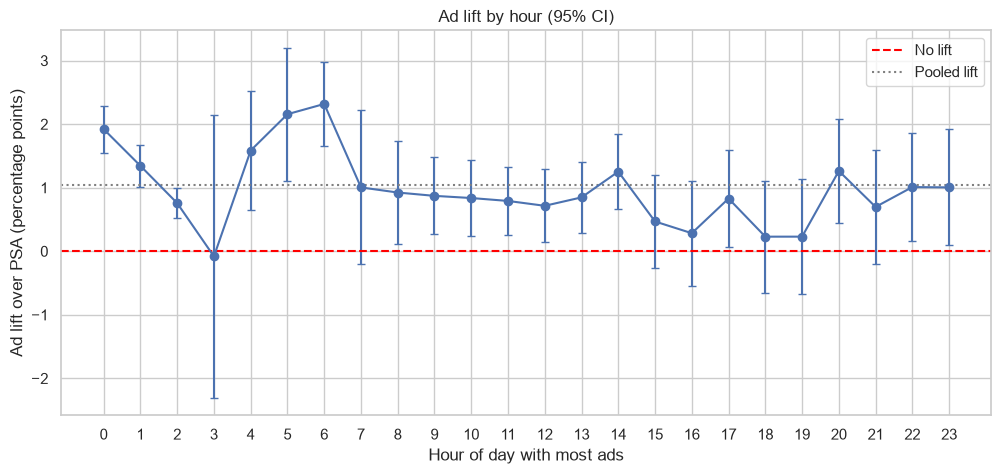

In [27]:


# 1. Overall chi-square and effect size
ct = pd.crosstab(df['most ads hour'], df['converted'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
v = np.sqrt(chi2 / len(df))
print(f"Hour: chi2 = {chi2:.1f}, dof = {dof}, p = {p:.3g}, Cramér's V = {v:.4f}")

# 2. Lift (ad - psa) by hour with 95% CI
rows = []
for h in sorted(df['most ads hour'].unique()):
    a = df[(df['test group']=='ad')  & (df['most ads hour']==h)]['converted']
    c = df[(df['test group']=='psa') & (df['most ads hour']==h)]['converted']
    pa, pc = a.mean(), c.mean()
    se = np.sqrt(pa*(1-pa)/len(a) + pc*(1-pc)/len(c))
    rows.append((h, len(a), len(c), pa, pc, pa-pc, se))

lift_h = pd.DataFrame(rows, columns=['hour','n_ad','n_psa','rate_ad','rate_psa','lift','se'])
lift_h['ci_low']  = lift_h['lift'] - 1.96*lift_h['se']
lift_h['ci_high'] = lift_h['lift'] + 1.96*lift_h['se']
print(lift_h.round(4).to_string(index=False))

# 3. Cochran's Q and I² for heterogeneity across hours
w = 1 / lift_h['se']**2
pooled = (w * lift_h['lift']).sum() / w.sum()
Q = (w * (lift_h['lift'] - pooled)**2).sum()
k = len(lift_h)
p_het = stats.chi2.sf(Q, df=k-1)
I2 = max(0, (Q - (k-1)) / Q)
print(f"\nPooled lift = {pooled:.4%}")
print(f"Cochran's Q = {Q:.2f}, dof = {k-1}, p = {p_het:.4g}, I² = {I2:.1%}")

# 4. Plot lift by hour with error bars
plt.figure(figsize=(12,5))
plt.errorbar(lift_h['hour'], lift_h['lift']*100,
             yerr=1.96*lift_h['se']*100, fmt='o-', capsize=3)
plt.axhline(0, color='red', linestyle='--', label='No lift')
plt.axhline(pooled*100, color='gray', linestyle=':', label='Pooled lift')
plt.xlabel('Hour of day with most ads')
plt.ylabel('Ad lift over PSA (percentage points)')
plt.title('Ad lift by hour (95% CI)')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

In [28]:
def hour_lift_table(df, hours):
    rows = []
    for h in hours:
        a = df[(df['test group']=='ad')  & (df['most ads hour']==h)]['converted']
        c = df[(df['test group']=='psa') & (df['most ads hour']==h)]['converted']
        xa, na, xc, nc = a.sum(), len(a), c.sum(), len(c)
        # Agresti-Caffo: add 1 success and 1 failure to each group
        pa, pc = (xa+1)/(na+2), (xc+1)/(nc+2)
        diff = pa - pc
        se = np.sqrt(pa*(1-pa)/(na+2) + pc*(1-pc)/(nc+2))
        rows.append((h, na, nc, xa/na, xc/nc, diff, se,
                     diff-1.96*se, diff+1.96*se))
    return pd.DataFrame(rows, columns=['hour','n_ad','n_psa','rate_ad','rate_psa',
                                       'lift','se','ci_low','ci_high'])

def heterogeneity(t):
    w = 1 / t['se']**2
    pooled = (w * t['lift']).sum() / w.sum()
    Q = (w * (t['lift'] - pooled)**2).sum()
    k = len(t)
    return pooled, Q, k-1, stats.chi2.sf(Q, k-1), max(0, (Q-(k-1))/Q)

all_hours = sorted(df['most ads hour'].unique())

for label, hrs in [("All 24 hours", all_hours),
                   ("Hours 8-23 only (PSA n >= 500)", [h for h in all_hours if h >= 8])]:
    t = hour_lift_table(df, hrs)
    pooled, Q, dof, p, I2 = heterogeneity(t)
    print(f"\n{label}")
    print(f"Pooled lift = {pooled:.4%}, Q = {Q:.2f}, dof = {dof}, p = {p:.4g}, I² = {I2:.1%}")
    if hrs[0] == 8:
        print(t.round(4).to_string(index=False))


All 24 hours
Pooled lift = 0.7388%, Q = 15.12, dof = 23, p = 0.8904, I² = 0.0%

Hours 8-23 only (PSA n >= 500)
Pooled lift = 0.7305%, Q = 9.17, dof = 15, p = 0.8683, I² = 0.0%
 hour  n_ad  n_psa  rate_ad  rate_psa   lift     se  ci_low  ci_high
    8 16968    659   0.0199    0.0106 0.0078 0.0044 -0.0008   0.0164
    9 29802   1202   0.0195    0.0108 0.0079 0.0032  0.0017   0.0142
   10 37454   1485   0.0218    0.0135 0.0077 0.0032  0.0016   0.0139
   11 44149   2061   0.0225    0.0146 0.0075 0.0028  0.0020   0.0129
   12 45238   2060   0.0241    0.0170 0.0067 0.0030  0.0009   0.0125
   13 45485   2170   0.0251    0.0166 0.0080 0.0029  0.0024   0.0137
   14 43779   1869   0.0286    0.0161 0.0120 0.0031  0.0060   0.0180
   15 42855   1828   0.0298    0.0252 0.0042 0.0038 -0.0032   0.0116
   16 35963   1604   0.0309    0.0281 0.0023 0.0043 -0.0061   0.0106
   17 33605   1383   0.0285    0.0202 0.0076 0.0040 -0.0001   0.0154
   18 31052   1271   0.0275    0.0252 0.0016 0.0045 -0.0073   0.